<a href="https://colab.research.google.com/github/roshitniraula/MachineLearning_CIS-631/blob/busrat/mBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


In [ ]:
import importlib
import json
import os
import random
import re
import subprocess
import sys
import unicodedata
from pathlib import Path


def ensure_packages(packages):
    missing = []
    for import_name, package_name in packages:
        try:
            importlib.import_module(import_name)
        except ImportError:
            missing.append(package_name)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


ensure_packages(
    [
        ("pandas", "pandas"),
        ("numpy", "numpy"),
        ("sklearn", "scikit-learn"),
        ("torch", "torch"),
        ("datasets", "datasets"),
        ("transformers", "transformers"),
        ("evaluate", "evaluate"),
        ("iterstrat", "iterative-stratification"),
        ("openpyxl", "openpyxl"),
        ("matplotlib", "matplotlib"),
    ]
)

from datasets import Dataset, DatasetDict
from IPython.display import display
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import classification_report, f1_score, hamming_loss, jaccard_score, multilabel_confusion_matrix, precision_recall_fscore_support
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [ ]:
#Load dataset
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

DATA_CANDIDATES = [
    Path("/content/drive/MyDrive/Dataset/HateSpeechData.xlsx"),
    Path("/content/drive/MyDrive/HateSpeechData.xlsx"),
    Path("/content/HateSpeechData.xlsx"),
    Path("./HateSpeechData.xlsx"),
    Path("/content/sample_hatespeech_bn_ne.csv"),
    Path("./sample_hatespeech_bn_ne.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Put an .xlsx or .csv file in one of DATA_CANDIDATES or edit the path list."
    )

if DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH)
print(f"Using dataset: {DATA_PATH}")
print("Raw shape:", df.shape)
df.head()

Mounted at /content/drive
Using dataset: /content/drive/MyDrive/Dataset/HateSpeechData.xlsx
Raw shape: (46682, 7)


,Comment,Hate/NoHate,Insult,Violence,Sexual,Racism,Religious
0,भाक भोसडीके,1,0,0,0,0,0
1,पिक्चर स्पीक्स वाक मुजी,1,1,0,0,0,0
2,हे मुजी....,1,0,0,0,0,0
3,लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️,1,1,0,0,0,0
4,आयो एमजी को कडा पर्सुस्तति♥️♥️♥️,1,0,0,0,0,0


In [ ]:
#2 CLEAN DATA
TEXT_COL = "comment"
LABEL_COLS = ["hate/nohate", "insult", "violence", "sexual", "racism", "religious"]
BINARY_LABEL = "hate/nohate"
SUBTYPE_COLS = [label for label in LABEL_COLS if label != BINARY_LABEL]

df.columns = df.columns.astype(str).str.strip()
missing_cols = [col for col in [TEXT_COL] + LABEL_COLS if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

df = df[[TEXT_COL] + LABEL_COLS].copy()
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)

for col in LABEL_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(0, 1).astype(int)

inconsistent_mask = (df["hate/nohate"] == 0) & (df[LABEL_COLS[1:]].sum(axis=1) > 0)
if inconsistent_mask.any():
    print("Fixing inconsistent rows where subtype=1 but Hate/NoHate=0:", int(inconsistent_mask.sum()))
    df.loc[inconsistent_mask, "hate/nohate"] = 1

print("Dataset shape after schema selection:", df.shape)
display(df.head())
display(pd.DataFrame({"positive_count": df[LABEL_COLS].sum(), "positive_ratio": df[LABEL_COLS].mean().round(4)}))

Dataset shape after schema selection: (46234, 7)


,comment,hate/nohate,insult,violence,sexual,racism,religious
0,भाक भोसडीके,1,0,0,0,0,0
1,पिक्चर स्पीक्स वाक मुजी,1,1,0,0,0,0
2,हे मुजी....,1,0,0,0,0,0
3,लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️,1,1,0,0,0,0
4,आयो एमजी को कडा पर्सुस्तति♥️♥️♥️,1,0,0,0,0,0


,positive_count,positive_ratio
hate/nohate,17383,0.3760
insult,12973,0.2806
violence,3328,0.0720
sexual,6681,0.1445
racism,2281,0.0493
religious,3127,0.0676


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.dropna(subset=[TEXT_COL, LABEL_COL])

USER_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
CONTROL_SPACE_PATTERN = re.compile(r"[\r\n\t]+")
MULTISPACE_PATTERN = re.compile(r"\s+")
REPEATED_PUNCT_PATTERN = re.compile(r"([!?.,])\1+")
EMOJI_PATTERN = re.compile(
    "[\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251]+",
    flags=re.UNICODE
)

def clean_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = USER_PATTERN.sub("USER", text)
    text = HASHTAG_PATTERN.sub(r"\1", text)
    text = EMOJI_PATTERN.sub("", text)
    text = re.sub(r"[^\w\s!?.,\u0900-\u097F\u0980-\u09FF]", " ", text)
    text = REPEATED_PUNCT_PATTERN.sub(r"\1", text)
    text = CONTROL_SPACE_PATTERN.sub(" ", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text

# Before cleaning
print("=== Before Cleaning ===")
print(df[TEXT_COL].head(), "\n")

df["clean_text"] = df[TEXT_COL].apply(clean_text)

# After cleaning
print("=== After Cleaning ===")
print(df[["comment","clean_text"]].head(), "\n")

# Keep track of initial rows
before_rows = len(df)

# Remove empty cleaned texts
df = df[df["text"].str.len() > 0].copy()

# Drop duplicates based on text + labels
df = df.drop_duplicates(subset=["text"] + LABEL_COLS).reset_index(drop=True)

# Add text stats
df["label_cardinality"] = df[LABEL_COLS].sum(axis=1)
df["char_len"] = df["text"].str.len()
df["cleaning_changed"] = (df[TEXT_COL].astype(str).str.strip() != df["text"])

# Reporting

print("Rows removed during cleanup:", before_rows - len(df))
print("Rows changed by cleaning:", int(df["cleaning_changed"].sum()))

# Show samples
display(df[[TEXT_COL, "text", "cleaning_changed", "label_cardinality", "char_len"]].head(10))
display(df.loc[df["cleaning_changed"], [TEXT_COL, "text"]].head(10))
display(df[["label_cardinality", "char_len"]].describe().round(2))


=== Before Cleaning ===
0                         भाक भोसडीके
1             पिक्चर स्पीक्स वाक मुजी
2                         हे मुजी....
3    लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️
4    आयो एमजी को कडा पर्सुस्तति♥️♥️♥️
Name: comment, dtype: object 

=== After Cleaning ===
                            comment                  clean_text
0                       भाक भोसडीके                 भाक भोसडीके
1           पिक्चर स्पीक्स वाक मुजी     पिक्चर स्पीक्स वाक मुजी
2                       हे मुजी....                    हे मुजी.
3  लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️    लस्तैइ ह्यान्डसम के मुजी
4  आयो एमजी को कडा पर्सुस्तति♥️♥️♥️  आयो एमजी को कडा पर्सुस्तति 

Rows removed during cleanup: 0
Rows changed by cleaning: 24815


,comment,text,cleaning_changed,label_cardinality,char_len
0,भाक भोसडीके,भाक भोसडीके,False,1,11
1,पिक्चर स्पीक्स वाक मुजी,पिक्चर स्पीक्स वाक मुजी,False,2,23
2,हे मुजी....,हे मुजी.,True,1,8
3,लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️,लस्तैइ ह्यान्डसम के मुजी 🤣,True,2,26
4,आयो एमजी को कडा पर्सुस्तति♥️♥️♥️,आयो एमजी को कडा पर्सुस्तति,True,1,26
5,दाजु बे लाइक :- केरा हेरो भाको होस भेट्लास,दाजु बे लाइक :- केरा हेरो भाको होस भेट्लास,False,2,42
6,हे वास सेइङ घण्टा 😁😁,हे वास सेइङ घण्टा,True,2,17
7,बोका🤣😂🤣,बोका🤣🤣,True,1,6
8,आईएफ चुटिइया ठगुवा हद आ फेस 😆😂,आईएफ चुटिइया ठगुवा हद आ फेस,True,0,27
9,काण्ड नि हर्क्सु \nक्ति को बी र तिग्रा नि हर्क...,काण्ड नि हर्क्सु क्ति को बी र तिग्रा नि हर्क्स...,True,2,171


,comment,text
2,हे मुजी....,हे मुजी.
3,लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️,लस्तैइ ह्यान्डसम के मुजी 🤣
4,आयो एमजी को कडा पर्सुस्तति♥️♥️♥️,आयो एमजी को कडा पर्सुस्तति
6,हे वास सेइङ घण्टा 😁😁,हे वास सेइङ घण्टा
7,बोका🤣😂🤣,बोका🤣🤣
8,आईएफ चुटिइया ठगुवा हद आ फेस 😆😂,आईएफ चुटिइया ठगुवा हद आ फेस
9,काण्ड नि हर्क्सु \nक्ति को बी र तिग्रा नि हर्क...,काण्ड नि हर्क्सु क्ति को बी र तिग्रा नि हर्क्स...
10,बस कर पगले ...रुलायेगा क्या 😭😭,बस कर पगले .रुलायेगा क्या
12,जिन्दगीमा भेज म:म पनि मिठो मानेर खाने दिन आयो😂😆😅,जिन्दगीमा भेज म:म पनि मिठो मानेर खाने दिन आयो
13,आर्य भाइ मेरा जैसा बाल कुन राख्था ही.😮,आर्य भाइ मेरा जैसा बाल कुन राख्था ही.


,label_cardinality,char_len
count,46231.00,46231.00
mean,0.99,78.26
std,1.38,119.85
min,0.00,4.00
25%,0.00,27.00
50%,0.00,48.00
75%,2.00,87.00
max,6.00,3202.00


In [ ]:
# STEP 2-9:( Clean, Drop Duplicates)
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
USER_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
CONTROL_SPACE_PATTERN = re.compile(r"[\r\n\t]+")
MULTISPACE_PATTERN = re.compile(r"\s+")
REPEATED_PUNCT_PATTERN = re.compile(r"([!?.,])\1+")
EMOJI_PATTERN = re.compile(
    "[\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251]+",
    flags=re.UNICODE
)

# Cleaning Configuration

CLEANING_CONFIG = {
    "replace_urls": True,
    "replace_users": True,
    "unwrap_hashtags": True,
    "collapse_repeated_punct": True,
    "remove_emojis": True
}


# Normalization Function

def normalize_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\u200b", " ").replace("\ufeff", " ")
    text = CONTROL_SPACE_PATTERN.sub(" ", text)

    if CLEANING_CONFIG["replace_urls"]:
        text = URL_PATTERN.sub(" [URL] ", text)
    if CLEANING_CONFIG["replace_users"]:
        text = USER_PATTERN.sub(" [USER] ", text)
    if CLEANING_CONFIG["unwrap_hashtags"]:
        text = HASHTAG_PATTERN.sub(r" \1 ", text)
    if CLEANING_CONFIG["collapse_repeated_punct"]:
        text = REPEATED_PUNCT_PATTERN.sub(r"\1", text)
    if CLEANING_CONFIG["remove_emojis"]:
        text = EMOJI_PATTERN.sub("", text)

    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text

# Apply Cleaning
clean_text = normalize_text
df["text"] = df[TEXT_COL].map(clean_text)

# Keep track of initial rows
before_rows = len(df)
# Remove empty cleaned texts
df = df[df["text"].str.len() > 0].copy()
# Drop duplicates based on text + labels
df = df.drop_duplicates(subset=["text"] + LABEL_COLS).reset_index(drop=True)
# Add text stats
df["label_cardinality"] = df[LABEL_COLS].sum(axis=1)
df["char_len"] = df["text"].str.len()
df["cleaning_changed"] = (df[TEXT_COL].astype(str).str.strip() != df["text"])

# Reporting

print("Rows removed during cleanup:", before_rows - len(df))
print("Rows changed by cleaning:", int(df["cleaning_changed"].sum()))

# Show samples
display(df[[TEXT_COL, "text", "cleaning_changed", "label_cardinality", "char_len"]].head(10))
display(df.loc[df["cleaning_changed"], [TEXT_COL, "text"]].head(10))
display(df[["label_cardinality", "char_len"]].describe().round(2))

Rows removed during cleanup: 0
Rows changed by cleaning: 24815


,comment,text,cleaning_changed,label_cardinality,char_len
0,भाक भोसडीके,भाक भोसडीके,False,1,11
1,पिक्चर स्पीक्स वाक मुजी,पिक्चर स्पीक्स वाक मुजी,False,2,23
2,हे मुजी....,हे मुजी.,True,1,8
3,लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️,लस्तैइ ह्यान्डसम के मुजी 🤣,True,2,26
4,आयो एमजी को कडा पर्सुस्तति♥️♥️♥️,आयो एमजी को कडा पर्सुस्तति,True,1,26
5,दाजु बे लाइक :- केरा हेरो भाको होस भेट्लास,दाजु बे लाइक :- केरा हेरो भाको होस भेट्लास,False,2,42
6,हे वास सेइङ घण्टा 😁😁,हे वास सेइङ घण्टा,True,2,17
7,बोका🤣😂🤣,बोका🤣🤣,True,1,6
8,आईएफ चुटिइया ठगुवा हद आ फेस 😆😂,आईएफ चुटिइया ठगुवा हद आ फेस,True,0,27
9,काण्ड नि हर्क्सु \nक्ति को बी र तिग्रा नि हर्क...,काण्ड नि हर्क्सु क्ति को बी र तिग्रा नि हर्क्स...,True,2,171


,comment,text
2,हे मुजी....,हे मुजी.
3,लस्तैइ ह्यान्डसम के मुजी 🤣❤️❤️❤️,लस्तैइ ह्यान्डसम के मुजी 🤣
4,आयो एमजी को कडा पर्सुस्तति♥️♥️♥️,आयो एमजी को कडा पर्सुस्तति
6,हे वास सेइङ घण्टा 😁😁,हे वास सेइङ घण्टा
7,बोका🤣😂🤣,बोका🤣🤣
8,आईएफ चुटिइया ठगुवा हद आ फेस 😆😂,आईएफ चुटिइया ठगुवा हद आ फेस
9,काण्ड नि हर्क्सु \nक्ति को बी र तिग्रा नि हर्क...,काण्ड नि हर्क्सु क्ति को बी र तिग्रा नि हर्क्स...
10,बस कर पगले ...रुलायेगा क्या 😭😭,बस कर पगले .रुलायेगा क्या
12,जिन्दगीमा भेज म:म पनि मिठो मानेर खाने दिन आयो😂😆😅,जिन्दगीमा भेज म:म पनि मिठो मानेर खाने दिन आयो
13,आर्य भाइ मेरा जैसा बाल कुन राख्था ही.😮,आर्य भाइ मेरा जैसा बाल कुन राख्था ही.


,label_cardinality,char_len
count,46231.00,46231.00
mean,0.99,78.26
std,1.38,119.85
min,0.00,4.00
25%,0.00,27.00
50%,0.00,48.00
75%,2.00,87.00
max,6.00,3202.00


In [ ]:

# STEP 10: Handle Class Imbalance

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(df[LABEL_COL]), y=df[LABEL_COL])
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.8013, 1.3298])


In [ ]:
# STEP 11: mBERT Tokenization

MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = HateSpeechDataset(X_train, y_train, tokenizer)
test_dataset = HateSpeechDataset(X_test, y_test, tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:

# STEP 12: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df[LABEL_COL], test_size=0.2, random_state=42, stratify=df[LABEL_COL]
)

In [ ]:
labels_matrix = df[LABEL_COLS].values

outer_splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, temp_idx = next(outer_splitter.split(df["text"], labels_matrix))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

inner_splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(inner_splitter.split(temp_df["text"], temp_df[LABEL_COLS].values))

val_df = temp_df.iloc[val_rel_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_rel_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
    }
)
split_summary["ratio"] = (split_summary["rows"] / len(df)).round(4)
display(split_summary)

for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"\n{split_name} label prevalence")
    display(split_df[LABEL_COLS].mean().round(4).to_frame("positive_ratio"))

,split,rows,ratio
0,train,36984,0.8
1,validation,4623,0.1
2,test,4624,0.1



train label prevalence


,positive_ratio
hate/nohate,0.3760
insult,0.2806
violence,0.0720
sexual,0.1445
racism,0.0493
religious,0.0677



validation label prevalence


,positive_ratio
hate/nohate,0.3759
insult,0.2806
violence,0.0720
sexual,0.1445
racism,0.0493
religious,0.0675



test label prevalence


,positive_ratio
hate/nohate,0.3761
insult,0.2807
violence,0.0720
sexual,0.1445
racism,0.0493
religious,0.0677


In [ ]:

# STEP 13: Load mBERT Model with Class Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

# Modify loss to use class weights
from torch.nn import CrossEntropyLoss

original_forward = model.forward

def forward_with_weights(**kwargs):
    labels = kwargs.get('labels', None)
    outputs = original_forward(**kwargs)
    logits = outputs.logits
    if labels is not None:
        loss_fct = CrossEntropyLoss(weight=class_weights.to(device))
        loss = loss_fct(logits, labels)
        return type(outputs)(loss=loss, logits=logits)
    return outputs

model.forward = forward_with_weights

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def frame_to_binary_dataset(frame):
    return Dataset.from_dict(
        {
            "text": frame["text"].tolist(),
            "labels": frame[BINARY_LABEL].astype(int).tolist(),
        }
    )


def frame_to_subtype_dataset(frame):
    frame = frame[frame[BINARY_LABEL] == 1].reset_index(drop=True)
    return Dataset.from_dict(
        {
            "text": frame["text"].tolist(),
            "labels": frame[SUBTYPE_COLS].astype(np.float32).values.tolist(),
        }
    )


binary_dataset = DatasetDict(
    {
        "train": frame_to_binary_dataset(train_df),
        "validation": frame_to_binary_dataset(val_df),
        "test": frame_to_binary_dataset(test_df),
    }
)

subtype_train_df = train_df[train_df[BINARY_LABEL] == 1].reset_index(drop=True)
subtype_val_df = val_df[val_df[BINARY_LABEL] == 1].reset_index(drop=True)
subtype_test_df = test_df[test_df[BINARY_LABEL] == 1].reset_index(drop=True)

if min(len(subtype_train_df), len(subtype_val_df), len(subtype_test_df)) == 0:
    raise ValueError("Subtype split is empty. Increase data size or adjust the split before stage-2 training.")

subtype_dataset = DatasetDict(
    {
        "train": frame_to_subtype_dataset(train_df),
        "validation": frame_to_subtype_dataset(val_df),
        "test": frame_to_subtype_dataset(test_df),
    }
)

MAX_LENGTH = 128
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


binary_tokenized = binary_dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
subtype_tokenized = subtype_dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

display(
    pd.DataFrame(
        {
            "split": ["train", "validation", "test"],
            "binary_rows": [len(train_df), len(val_df), len(test_df)],
            "subtype_rows": [len(subtype_train_df), len(subtype_val_df), len(subtype_test_df)],
        }
    )
)
print("Binary and subtype datasets are ready.")

Map:   0%|          | 0/36984 [00:00<?, ? examples/s]

Map:   0%|          | 0/4623 [00:00<?, ? examples/s]

Map:   0%|          | 0/4624 [00:00<?, ? examples/s]

Map:   0%|          | 0/13906 [00:00<?, ? examples/s]

Map:   0%|          | 0/1738 [00:00<?, ? examples/s]

Map:   0%|          | 0/1739 [00:00<?, ? examples/s]

,split,binary_rows,subtype_rows
0,train,36984,13906
1,validation,4623,1738
2,test,4624,1739


Binary and subtype datasets are ready.


In [ ]:
binary_counts = train_df[BINARY_LABEL].value_counts().reindex([0, 1], fill_value=0)
binary_class_weights = len(train_df) / (2.0 * np.maximum(binary_counts.values.astype(np.float32), 1.0))

subtype_positive = subtype_train_df[SUBTYPE_COLS].sum(axis=0).values.astype(np.float32)
subtype_negative = (len(subtype_train_df) - subtype_positive).astype(np.float32)
subtype_pos_weight = np.clip(subtype_negative / np.maximum(subtype_positive, 1.0), 1.0, 25.0)

display(
    pd.DataFrame(
        {
            "class": ["NoHate", "Hate"],
            "count": binary_counts.values.astype(int),
            "class_weight": binary_class_weights.round(3),
        }
    )
)

display(
    pd.DataFrame(
        {
            "label": SUBTYPE_COLS,
            "positive_examples": subtype_positive.astype(int),
            "negative_examples": subtype_negative.astype(int),
            "pos_weight": subtype_pos_weight.round(3),
        }
    )
)

binary_threshold = 0.5
subtype_thresholds = np.full(len(SUBTYPE_COLS), 0.5, dtype=np.float32)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sigmoid_np(logits):
    logits = np.asarray(logits)
    return 1.0 / (1.0 + np.exp(-logits))


def softmax_np(logits):
    logits = np.asarray(logits)
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def combine_hierarchical_predictions(hate_preds, subtype_preds):
    hate_preds = np.asarray(hate_preds).astype(int).reshape(-1, 1)
    subtype_preds = np.asarray(subtype_preds).astype(int)
    if subtype_preds.ndim == 1:
        subtype_preds = subtype_preds.reshape(-1, len(SUBTYPE_COLS))
    combined = np.concatenate([hate_preds, subtype_preds], axis=1)
    combined[hate_preds[:, 0] == 0, 1:] = 0
    return combined


def combined_metrics(true_labels, pred_labels):
    true_labels = np.asarray(true_labels).astype(int)
    pred_labels = np.asarray(pred_labels).astype(int)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average="micro", zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average="macro", zero_division=0
    )
    samples_f1 = f1_score(true_labels, pred_labels, average="samples", zero_division=0)
    exact_match = float((pred_labels == true_labels).all(axis=1).mean())
    sample_jaccard = jaccard_score(true_labels, pred_labels, average="samples", zero_division=0)
    return {
        "micro_f1": float(f1_micro),
        "macro_f1": float(f1_macro),
        "micro_precision": float(precision_micro),
        "micro_recall": float(recall_micro),
        "macro_precision": float(precision_macro),
        "macro_recall": float(recall_macro),
        "samples_f1": float(samples_f1),
        "exact_match": exact_match,
        "hamming_loss": float(hamming_loss(true_labels, pred_labels)),
        "sample_jaccard": float(sample_jaccard),
    }


def compute_binary_metrics(eval_pred):
    logits, labels = eval_pred
    labels = labels.astype(int)
    probs = softmax_np(logits)[:, 1]
    preds = (probs >= binary_threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    accuracy = float((preds == labels).mean())
    return {
        "binary_f1": float(f1),
        "binary_precision": float(precision),
        "binary_recall": float(recall),
        "binary_accuracy": accuracy,
    }


def compute_subtype_metrics(eval_pred):
    logits, labels = eval_pred
    labels = labels.astype(int)
    probs = sigmoid_np(logits)
    preds = (probs >= subtype_thresholds).astype(int)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    samples_f1 = f1_score(labels, preds, average="samples", zero_division=0)
    return {
        "micro_f1": float(f1_micro),
        "macro_f1": float(f1_macro),
        "micro_precision": float(precision_micro),
        "micro_recall": float(recall_micro),
        "macro_precision": float(precision_macro),
        "macro_recall": float(recall_macro),
        "samples_f1": float(samples_f1),
    }


def summarize_multilabel_confusion_matrices(true_labels, pred_labels, title):
    true_labels = np.asarray(true_labels).astype(int)
    pred_labels = np.asarray(pred_labels).astype(int)
    mcm = multilabel_confusion_matrix(true_labels, pred_labels)

    print(f"\n=== {title} ===")
    for i, label in enumerate(LABEL_COLS):
        tn, fp, fn, tp = mcm[i].ravel()
        acc = (tp + tn) / max(tp + tn + fp + fn, 1)
        print(f"\nLabel: {label}")
        print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}  Accuracy={acc:.4f}")

    print("\n=== Classification Report ===")
    print(classification_report(true_labels, pred_labels, target_names=LABEL_COLS, zero_division=0))
    return mcm


def plot_multilabel_confusion_matrices(true_labels, pred_labels, title, cols=3):
    true_labels = np.asarray(true_labels).astype(int)
    pred_labels = np.asarray(pred_labels).astype(int)
    mcm = multilabel_confusion_matrix(true_labels, pred_labels)
    rows = int(np.ceil(len(LABEL_COLS) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, label in enumerate(LABEL_COLS):
        tn, fp, fn, tp = mcm[i].ravel()
        cm = np.array([[tn, fp], [fn, tp]])
        ax = axes[i]
        ax.imshow(cm, cmap="coolwarm")
        ax.set_title(label)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["No", "Yes"])
        ax.set_yticklabels(["No", "Yes"])
        for r in range(2):
            for c in range(2):
                ax.text(c, r, cm[r, c], ha="center", va="center", color="black")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
    return mcm


def predict_model_logits(model, texts, batch_size=32):
    if len(texts) == 0:
        return np.empty((0, model.config.num_labels), dtype=np.float32)

    model.eval()
    device = next(model.parameters()).device
    logits_chunks = []

    for start in range(0, len(texts), batch_size):
        batch_texts = [normalize_text(text) for text in texts[start:start + batch_size]]
        encoded = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            batch_logits = model(**encoded).logits.detach().cpu().numpy()
        logits_chunks.append(batch_logits)

    return np.concatenate(logits_chunks, axis=0)


class BinaryTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = None if class_weights is None else torch.tensor(class_weights, dtype=torch.float32)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").long()
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


class MultiLabelTrainer(Trainer):
    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = None if pos_weight is None else torch.tensor(pos_weight, dtype=torch.float32)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.BCEWithLogitsLoss(
            pos_weight=self.pos_weight.to(logits.device) if self.pos_weight is not None else None
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


,class,count,class_weight
0,NoHate,23078,0.801
1,Hate,13906,1.330


,label,positive_examples,negative_examples,pos_weight
0,insult,10378,3528,1.000
1,violence,2662,11244,4.224
2,sexual,5345,8561,1.602
3,racism,1825,12081,6.620
4,religious,2502,11404,4.558


In [ ]:
#training argument

binary_id2label = {0: "NoHate", 1: "Hate"}
binary_label2id = {label: idx for idx, label in binary_id2label.items()}
subtype_id2label = {idx: label for idx, label in enumerate(SUBTYPE_COLS)}
subtype_label2id = {label: idx for idx, label in subtype_id2label.items()}

binary_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=binary_id2label,
    label2id=binary_label2id,
).to(DEVICE)

subtype_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(SUBTYPE_COLS),
    problem_type="multi_label_classification",
    id2label=subtype_id2label,
    label2id=subtype_label2id,
).to(DEVICE)

OUTPUT_DIR = "mbert_hierarchical_hatespeech"
BATCH_SIZE = 8 if torch.cuda.is_available() else 4
EVAL_BATCH_SIZE = 16 if torch.cuda.is_available() else 4
GRAD_ACCUM = 2 if torch.cuda.is_available() else 1


def build_training_arguments(output_dir, metric_for_best_model):
    training_kwargs = {
        "output_dir": output_dir,
        "num_train_epochs": 3,
        "learning_rate": 2e-5,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRAD_ACCUM,
        "warmup_ratio": 0.1,
        "weight_decay": 0.01,
        "save_strategy": "epoch",
        "logging_strategy": "steps",
        "logging_steps": 50,
        "load_best_model_at_end": True,
        "metric_for_best_model": metric_for_best_model,
        "greater_is_better": True,
        "save_total_limit": 2,
        "fp16": torch.cuda.is_available(),
        "report_to": "none",
        "seed": SEED,
    }

    ta_params = set(TrainingArguments.__init__.__code__.co_varnames)
    if "evaluation_strategy" in ta_params:
        training_kwargs["evaluation_strategy"] = "epoch"
    elif "eval_strategy" in ta_params:
        training_kwargs["eval_strategy"] = "epoch"
    else:
        raise TypeError("Neither 'evaluation_strategy' nor 'eval_strategy' exists in this transformers version.")

    if "gradient_checkpointing" in ta_params:
        training_kwargs["gradient_checkpointing"] = torch.cuda.is_available()
    if "group_by_length" in ta_params:
        training_kwargs["group_by_length"] = True

    return TrainingArguments(**training_kwargs)


binary_training_args = build_training_arguments(str(Path(OUTPUT_DIR) / "stage1_hate"), "binary_f1")
subtype_training_args = build_training_arguments(str(Path(OUTPUT_DIR) / "stage2_subtypes"), "micro_f1")

binary_trainer = BinaryTrainer(
    model=binary_model,
    args=binary_training_args,
    train_dataset=binary_tokenized["train"],
    eval_dataset=binary_tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_binary_metrics,
    class_weights=binary_class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

subtype_trainer = MultiLabelTrainer(
    model=subtype_model,
    args=subtype_training_args,
    train_dataset=subtype_tokenized["train"],
    eval_dataset=subtype_tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_subtype_metrics,
    pos_weight=subtype_pos_weight,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Collecting before-training hierarchical logits...")
before_binary_val_logits = predict_model_logits(binary_model, val_df["text"].tolist())
before_binary_test_logits = predict_model_logits(binary_model, test_df["text"].tolist())
before_subtype_val_logits = predict_model_logits(subtype_model, val_df["text"].tolist())
before_subtype_test_logits = predict_model_logits(subtype_model, test_df["text"].tolist())

binary_train_result = binary_trainer.train()
subtype_train_result = subtype_trainer.train()

display(binary_train_result.metrics)
display(subtype_train_result.metrics)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated

Epoch,Training Loss,Validation Loss,Binary F1,Binary Precision,Binary Recall,Binary Accuracy
1,0.457423,0.295377,0.883854,0.881075,0.886651,0.912395


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': 1635.7178,
 'train_samples_per_second': 67.831,
 'train_steps_per_second': 4.24,
 'total_flos': 2267392408446720.0,
 'train_loss': 0.540629983773281,
 'epoch': 3.0}

{'train_runtime': 616.302,
 'train_samples_per_second': 67.691,
 'train_steps_per_second': 4.235,
 'total_flos': 893376540526752.0,
 'train_loss': 0.646976401888091,
 'epoch': 3.0}

,setting,value
0,hate_threshold,0.65


,label,threshold
0,insult,0.55
1,violence,0.85
2,sexual,0.75
3,racism,0.80
4,religious,0.80


,stage,micro_f1,macro_f1,micro_precision,micro_recall,macro_precision,macro_recall,samples_f1,exact_match,hamming_loss,sample_jaccard
0,before_train_validation,0.0340,0.0210,0.1770,0.0188,0.1818,0.0113,0.0048,0.6122,0.1763,0.0033
1,before_train_test,0.0220,0.0160,0.1322,0.0120,0.1515,0.0089,0.0030,0.6114,0.1761,0.0022
2,after_train_validation,0.8899,0.8908,0.8823,0.8977,0.8806,0.9015,0.3280,0.8743,0.0366,0.3208
3,after_train_test,0.8719,0.8639,0.8598,0.8843,0.8551,0.8731,0.3259,0.8592,0.0429,0.3183



=== Before Fine-Tuning: Hierarchical Test Split ===

Label: hate/nohate
TN=2827  FP=58  FN=1715  TP=24  Accuracy=0.6166

Label: insult
TN=3266  FP=60  FN=1276  TP=22  Accuracy=0.7111

Label: violence
TN=4212  FP=79  FN=330  TP=3  Accuracy=0.9115

Label: sexual
TN=3946  FP=10  FN=664  TP=4  Accuracy=0.8542

Label: racism
TN=4315  FP=81  FN=227  TP=1  Accuracy=0.9334

Label: religious
TN=4238  FP=73  FN=312  TP=1  Accuracy=0.9167

=== Classification Report ===
              precision    recall  f1-score   support

 hate/nohate       0.29      0.01      0.03      1739
      insult       0.27      0.02      0.03      1298
    violence       0.04      0.01      0.01       333
      sexual       0.29      0.01      0.01       668
      racism       0.01      0.00      0.01       228
   religious       0.01      0.00      0.01       313

   micro avg       0.13      0.01      0.02      4579
   macro avg       0.15      0.01      0.02      4579
weighted avg       0.23      0.01      0.02     

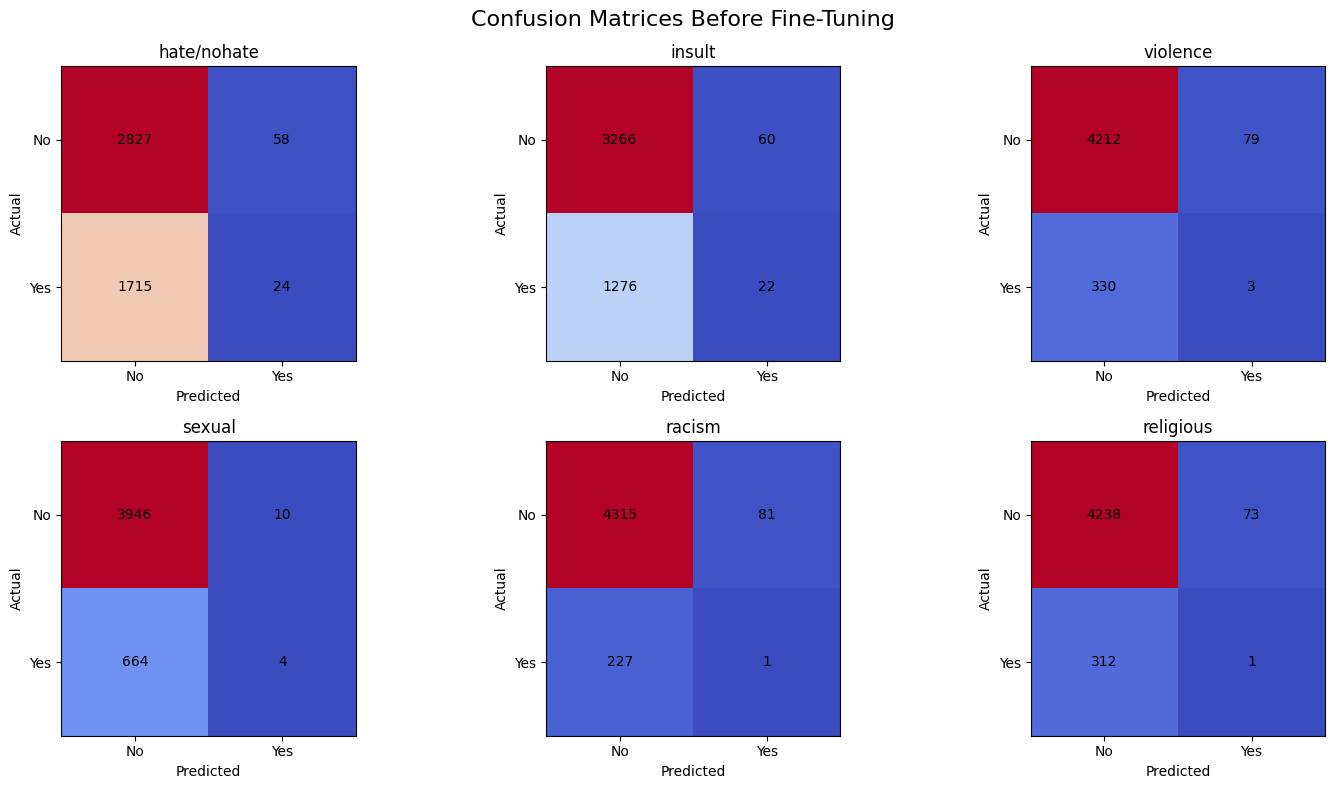


=== After Fine-Tuning: Hierarchical Test Split ===

Label: hate/nohate
TN=2673  FP=212  FN=174  TP=1565  Accuracy=0.9165

Label: insult
TN=3095  FP=231  FN=151  TP=1147  Accuracy=0.9174

Label: violence
TN=4218  FP=73  FN=76  TP=257  Accuracy=0.9678

Label: sexual
TN=3883  FP=73  FN=73  TP=595  Accuracy=0.9684

Label: racism
TN=4369  FP=27  FN=24  TP=204  Accuracy=0.9890

Label: religious
TN=4267  FP=44  FN=32  TP=281  Accuracy=0.9836

=== Classification Report ===
              precision    recall  f1-score   support

 hate/nohate       0.88      0.90      0.89      1739
      insult       0.83      0.88      0.86      1298
    violence       0.78      0.77      0.78       333
      sexual       0.89      0.89      0.89       668
      racism       0.88      0.89      0.89       228
   religious       0.86      0.90      0.88       313

   micro avg       0.86      0.88      0.87      4579
   macro avg       0.86      0.87      0.86      4579
weighted avg       0.86      0.88      0.

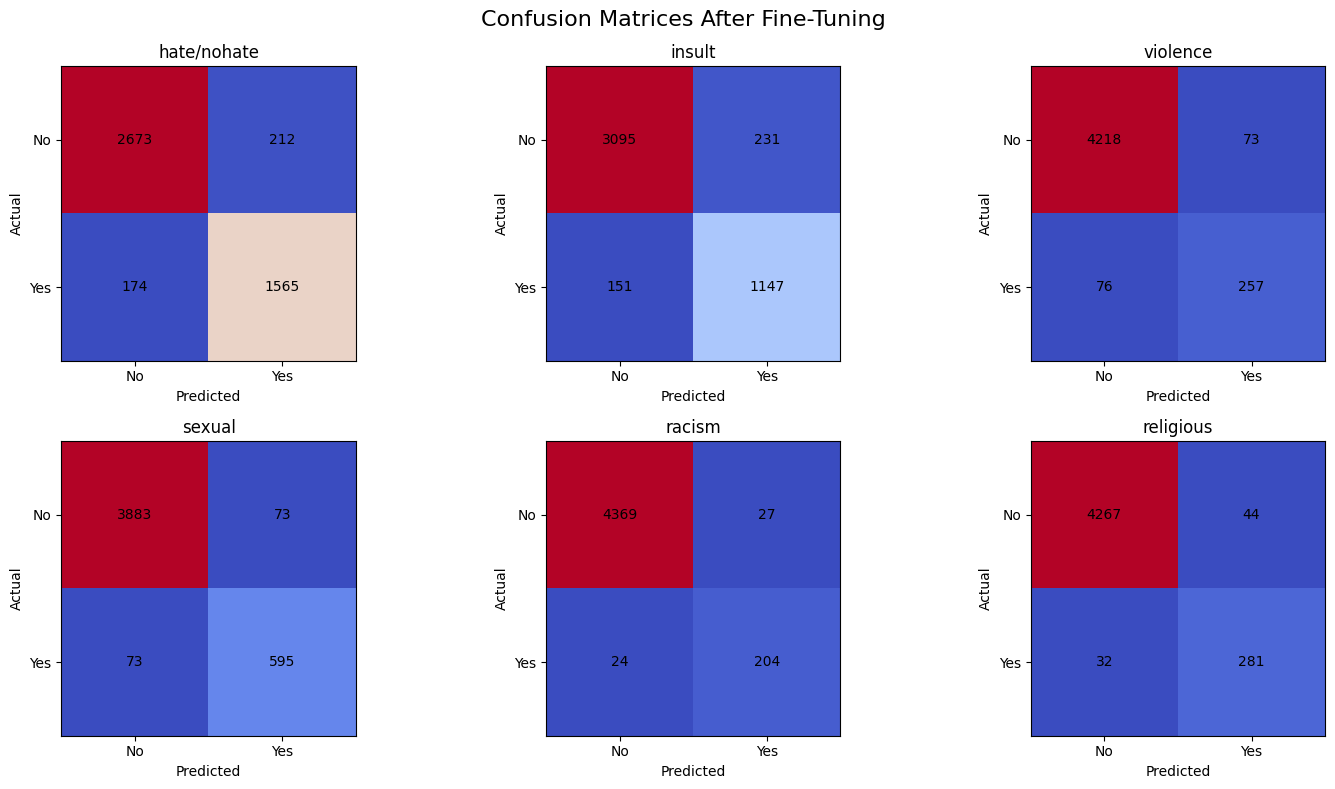

,precision,recall,f1-score,support
NoHate,0.6224,0.9799,0.7613,2885.0000
Hate,0.2927,0.0138,0.0264,1739.0000
accuracy,0.6166,0.6166,0.6166,0.6166
macro avg,0.4575,0.4968,0.3938,4624.0000
weighted avg,0.4984,0.6166,0.4849,4624.0000


,precision,recall,f1-score,support
NoHate,0.9389,0.9265,0.9327,2885.0000
Hate,0.8807,0.8999,0.8902,1739.0000
accuracy,0.9165,0.9165,0.9165,0.9165
macro avg,0.9098,0.9132,0.9114,4624.0000
weighted avg,0.9170,0.9165,0.9167,4624.0000


,precision,recall,f1-score,support
hate/nohate,0.2927,0.0138,0.0264,1739.0
insult,0.2683,0.0169,0.0319,1298.0
violence,0.0366,0.0090,0.0145,333.0
sexual,0.2857,0.0060,0.0117,668.0
racism,0.0122,0.0044,0.0065,228.0
religious,0.0135,0.0032,0.0052,313.0
micro avg,0.1322,0.0120,0.0220,4579.0
macro avg,0.1515,0.0089,0.0160,4579.0
weighted avg,0.2331,0.0120,0.0225,4579.0
samples avg,0.0024,0.0043,0.0030,4579.0


,precision,recall,f1-score,support
hate/nohate,0.8807,0.8999,0.8902,1739.0
insult,0.8324,0.8837,0.8572,1298.0
violence,0.7788,0.7718,0.7753,333.0
sexual,0.8907,0.8907,0.8907,668.0
racism,0.8831,0.8947,0.8889,228.0
religious,0.8646,0.8978,0.8809,313.0
micro avg,0.8598,0.8843,0.8719,4579.0
macro avg,0.8551,0.8731,0.8639,4579.0
weighted avg,0.8601,0.8843,0.8719,4579.0
samples avg,0.3272,0.3284,0.3259,4579.0


In [ ]:
def tune_binary_threshold(logits, true_labels, grid=None):
    if grid is None:
        grid = np.linspace(0.10, 0.90, 17)
    true_labels = np.asarray(true_labels).astype(int)
    probs = softmax_np(logits)[:, 1]

    best_threshold = 0.5
    best_score = -1.0
    for threshold in grid:
        preds = (probs >= threshold).astype(int)
        score = f1_score(true_labels, preds, zero_division=0)
        if score > best_score:
            best_score = score
            best_threshold = threshold
    return float(best_threshold)


def tune_subtype_thresholds(logits, true_labels, grid=None):
    if grid is None:
        grid = np.linspace(0.10, 0.90, 17)

    true_labels = np.asarray(true_labels).astype(int)
    probs = sigmoid_np(logits)
    best_thresholds = np.full(probs.shape[1], 0.5, dtype=np.float32)

    for i in range(probs.shape[1]):
        y_true = true_labels[:, i]
        if y_true.sum() == 0:
            continue

        best_score = -1.0
        best_threshold = 0.5
        for threshold in grid:
            y_pred = (probs[:, i] >= threshold).astype(int)
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_score:
                best_score = score
                best_threshold = threshold
        best_thresholds[i] = float(best_threshold)

    return best_thresholds


def hierarchical_predict(binary_logits, subtype_logits, hate_threshold, subtype_thresholds):
    hate_probs = softmax_np(binary_logits)[:, 1]
    hate_preds = (hate_probs >= hate_threshold).astype(int)
    subtype_probs = sigmoid_np(subtype_logits)
    subtype_preds = (subtype_probs >= np.asarray(subtype_thresholds)).astype(int)
    combined_preds = combine_hierarchical_predictions(hate_preds, subtype_preds)
    return hate_probs, hate_preds, subtype_probs, subtype_preds, combined_preds


def evaluate_hierarchical_predictions(frame, binary_logits, subtype_logits, hate_threshold, subtype_thresholds):
    true_combined = frame[LABEL_COLS].values.astype(int)
    hate_probs, hate_preds, subtype_probs, subtype_preds, combined_preds = hierarchical_predict(
        binary_logits, subtype_logits, hate_threshold, subtype_thresholds
    )
    overall = combined_metrics(true_combined, combined_preds)

    combined_report_df = pd.DataFrame(
        classification_report(
            true_combined,
            combined_preds,
            target_names=LABEL_COLS,
            zero_division=0,
            output_dict=True,
        )
    ).T

    binary_report_df = pd.DataFrame(
        classification_report(
            frame[BINARY_LABEL].values.astype(int),
            hate_preds,
            labels=[0, 1],
            target_names=["NoHate", "Hate"],
            zero_division=0,
            output_dict=True,
        )
    ).T

    return overall, combined_report_df, binary_report_df, hate_probs, subtype_probs, combined_preds


baseline_hate_threshold = 0.5
baseline_subtype_thresholds = np.full(len(SUBTYPE_COLS), 0.5, dtype=np.float32)

before_val_overall, before_val_report_df, before_val_binary_report_df, before_val_hate_probs, before_val_subtype_probs, before_val_preds = evaluate_hierarchical_predictions(
    val_df, before_binary_val_logits, before_subtype_val_logits, baseline_hate_threshold, baseline_subtype_thresholds
)
before_test_overall, before_test_report_df, before_test_binary_report_df, before_test_hate_probs, before_test_subtype_probs, before_test_preds = evaluate_hierarchical_predictions(
    test_df, before_binary_test_logits, before_subtype_test_logits, baseline_hate_threshold, baseline_subtype_thresholds
)

binary_val_logits = predict_model_logits(binary_trainer.model, val_df["text"].tolist())
binary_test_logits = predict_model_logits(binary_trainer.model, test_df["text"].tolist())
subtype_val_logits = predict_model_logits(subtype_trainer.model, val_df["text"].tolist())
subtype_test_logits = predict_model_logits(subtype_trainer.model, test_df["text"].tolist())
subtype_val_hate_logits = predict_model_logits(subtype_trainer.model, subtype_val_df["text"].tolist())

binary_threshold = tune_binary_threshold(binary_val_logits, val_df[BINARY_LABEL].values)
subtype_thresholds = tune_subtype_thresholds(subtype_val_hate_logits, subtype_val_df[SUBTYPE_COLS].values)

val_overall, val_report_df, val_binary_report_df, val_hate_probs, val_subtype_probs, val_preds = evaluate_hierarchical_predictions(
    val_df, binary_val_logits, subtype_val_logits, binary_threshold, subtype_thresholds
)
test_overall, test_report_df, test_binary_report_df, test_hate_probs, test_subtype_probs, test_preds = evaluate_hierarchical_predictions(
    test_df, binary_test_logits, subtype_test_logits, binary_threshold, subtype_thresholds
)

comparison_df = pd.DataFrame(
    [
        {"stage": "before_train_validation", **before_val_overall},
        {"stage": "before_train_test", **before_test_overall},
        {"stage": "after_train_validation", **val_overall},
        {"stage": "after_train_test", **test_overall},
    ]
).round(4)

display(pd.DataFrame({"setting": ["hate_threshold"], "value": [round(float(binary_threshold), 3)]}))
display(pd.DataFrame({"label": SUBTYPE_COLS, "threshold": subtype_thresholds.round(3)}))
display(comparison_df)

summarize_multilabel_confusion_matrices(
    test_df[LABEL_COLS].values, before_test_preds, "Before Fine-Tuning: Hierarchical Test Split"
)
plot_multilabel_confusion_matrices(
    test_df[LABEL_COLS].values, before_test_preds, "Confusion Matrices Before Fine-Tuning"
)

summarize_multilabel_confusion_matrices(
    test_df[LABEL_COLS].values, test_preds, "After Fine-Tuning: Hierarchical Test Split"
)
plot_multilabel_confusion_matrices(
    test_df[LABEL_COLS].values, test_preds, "Confusion Matrices After Fine-Tuning"
)

display(before_test_binary_report_df.round(4))
display(test_binary_report_df.round(4))
display(before_test_report_df.round(4))
display(test_report_df.round(4))

In [ ]:
output_root = Path(OUTPUT_DIR)
binary_output_path = output_root / "stage1_hate"
subtype_output_path = output_root / "stage2_subtypes"
binary_output_path.mkdir(parents=True, exist_ok=True)
subtype_output_path.mkdir(parents=True, exist_ok=True)

binary_trainer.save_model(binary_output_path)
subtype_trainer.save_model(subtype_output_path)
tokenizer.save_pretrained(binary_output_path)
tokenizer.save_pretrained(subtype_output_path)

with open(output_root / "hierarchical_config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": MODEL_NAME,
            "binary_label": BINARY_LABEL,
            "subtype_labels": SUBTYPE_COLS,
            "hate_threshold": float(binary_threshold),
            "subtype_thresholds": {label: float(th) for label, th in zip(SUBTYPE_COLS, subtype_thresholds)},
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print(f"Saved stage-1 model to: {binary_output_path.resolve()}")
print(f"Saved stage-2 model to: {subtype_output_path.resolve()}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved stage-1 model to: /content/mbert_hierarchical_hatespeech/stage1_hate
Saved stage-2 model to: /content/mbert_hierarchical_hatespeech/stage2_subtypes


In [ ]:
def predict_texts(texts, hate_threshold_override=None, subtype_thresholds_override=None):
    if hate_threshold_override is None:
        hate_threshold_override = binary_threshold
    if subtype_thresholds_override is None:
        subtype_thresholds_override = subtype_thresholds

    normalized_texts = [normalize_text(text) for text in texts]
    binary_logits = predict_model_logits(binary_trainer.model, texts)
    subtype_logits = predict_model_logits(subtype_trainer.model, texts)
    hate_probs, hate_preds, subtype_probs, subtype_preds, combined_preds = hierarchical_predict(
        binary_logits,
        subtype_logits,
        hate_threshold_override,
        subtype_thresholds_override,
    )

    rows = []
    for raw_text, normalized_text, hate_prob, subtype_prob_row, combined_row in zip(
        texts, normalized_texts, hate_probs, subtype_probs, combined_preds
    ):
        row = {
            "text": raw_text,
            "normalized_text": normalized_text,
            "Hate/NoHate_prob": round(float(hate_prob), 4),
            "Hate/NoHate": int(combined_row[0]),
        }
        for label, prob, pred in zip(SUBTYPE_COLS, subtype_prob_row, combined_row[1:]):
            row[f"{label}_prob"] = round(float(prob), 4)
            row[label] = int(pred)

        active_subtypes = [label for label in SUBTYPE_COLS if row[label] == 1]
        row["predicted_hate_type"] = ", ".join(active_subtypes) if active_subtypes else ("no_hate" if row["Hate/NoHate"] == 0 else "hate_without_subtype")
        rows.append(row)

    return pd.DataFrame(rows)


sample_examples = test_df[TEXT_COL].sample(min(5, len(test_df)), random_state=SEED).tolist()
predict_texts(sample_examples)


,text,normalized_text,Hate/NoHate_prob,Hate/NoHate,insult_prob,insult,violence_prob,violence,sexual_prob,sexual,racism_prob,racism,religious_prob,religious,predicted_hate_type
0,রুবেল জদি জাতীয় দলের খেলোয়ার না হতো ওকে জুতা প...,রুবেল জদি জাতীয় দলের খেলোয়ার না হতো ওকে জুতা...,0.0270,0,0.9786,0,0.9929,0,0.0558,0,0.0609,0,0.0166,0,no_hate
1,সাকিব এর বুক টা ফেটে যাচ্ছে ।।।আহ্ রে সালা চুত...,সাকিব এর বুক টা ফেটে যাচ্ছে ।।।আহ্ রে সালা চুত...,0.9927,1,0.9807,1,0.3162,0,0.6177,0,0.0073,0,0.0064,0,insult
2,ফারিয়া ফোন দেয়না সারিয়া🤣🤣🤣,ফারিয়া ফোন দেয়না সারিয়া🤣🤣🤣,0.0017,0,0.8870,0,0.0107,0,0.0979,0,0.0098,0,0.0043,0,no_hate
3,বেশ্যার ঘরে জন্ম নেওয়া সব গুলো ছাত্রলীগ করে,বেশ্যার ঘরে জন্ম নেওয়া সব গুলো ছাত্রলীগ করে,0.9992,1,0.9808,1,0.0384,0,0.9939,1,0.0291,0,0.0106,0,"insult, sexual"
4,किनारा,किनारा,0.0098,0,0.1518,0,0.0091,0,0.0158,0,0.2672,0,0.0054,0,no_hate


In [ ]:
# STEP 15: Metrics Function

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

--- Binary Model Evaluation ---


Binary Evaluation Results: {'eval_loss': 0.32210907340049744, 'eval_binary_f1': 0.8895168126589432, 'eval_binary_precision': 0.8744444444444445, 'eval_binary_recall': 0.9051178838412881, 'eval_binary_accuracy': 0.9154411764705882, 'eval_runtime': 6.284, 'eval_samples_per_second': 735.841, 'eval_steps_per_second': 45.99, 'epoch': 3.0}

Binary Classification Report:
              precision    recall  f1-score   support

      NoHate       0.63      0.61      0.62      2885
        Hate       0.38      0.39      0.39      1739

    accuracy                           0.53      4624
   macro avg       0.50      0.50      0.50      4624
weighted avg       0.53      0.53      0.53      4624


Binary Confusion Matrix:
[[1767 1118]
 [1057  682]]


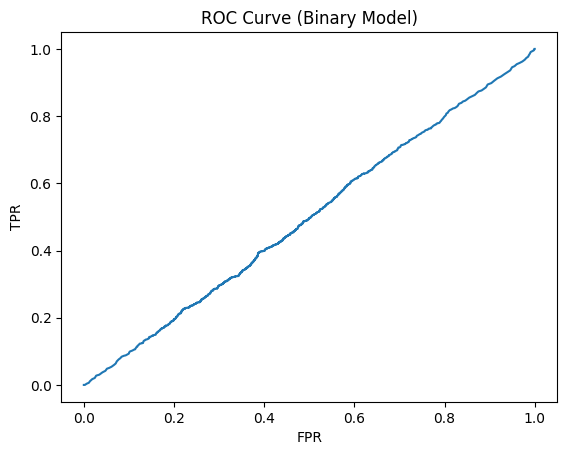


--- Subtype Model Evaluation (on Hate-classified texts) ---


Subtype Evaluation Results: {'eval_loss': 0.2502700686454773, 'eval_micro_f1': 0.9263339070567986, 'eval_macro_f1': 0.9108034430261986, 'eval_micro_precision': 0.906060606060606, 'eval_micro_recall': 0.9475352112676056, 'eval_macro_precision': 0.8891990219673451, 'eval_macro_recall': 0.9340488569244838, 'eval_samples_f1': 0.8674060078315396, 'eval_runtime': 2.0383, 'eval_samples_per_second': 853.167, 'eval_steps_per_second': 53.476, 'epoch': 3.0}

Subtype Classification Report:
              precision    recall  f1-score   support

      insult       0.76      0.79      0.77      1298
    violence       0.16      0.18      0.17       333
      sexual       0.37      0.38      0.37       668
      racism       0.08      0.09      0.09       228
   religious       0.12      0.12      0.12       313

   micro avg       0.47      0.49      0.48      2840
   macro avg       0.30      0.31      0.30      2840
weighted avg       0.47      0.49      0.48      2840
 samples avg       0.48      

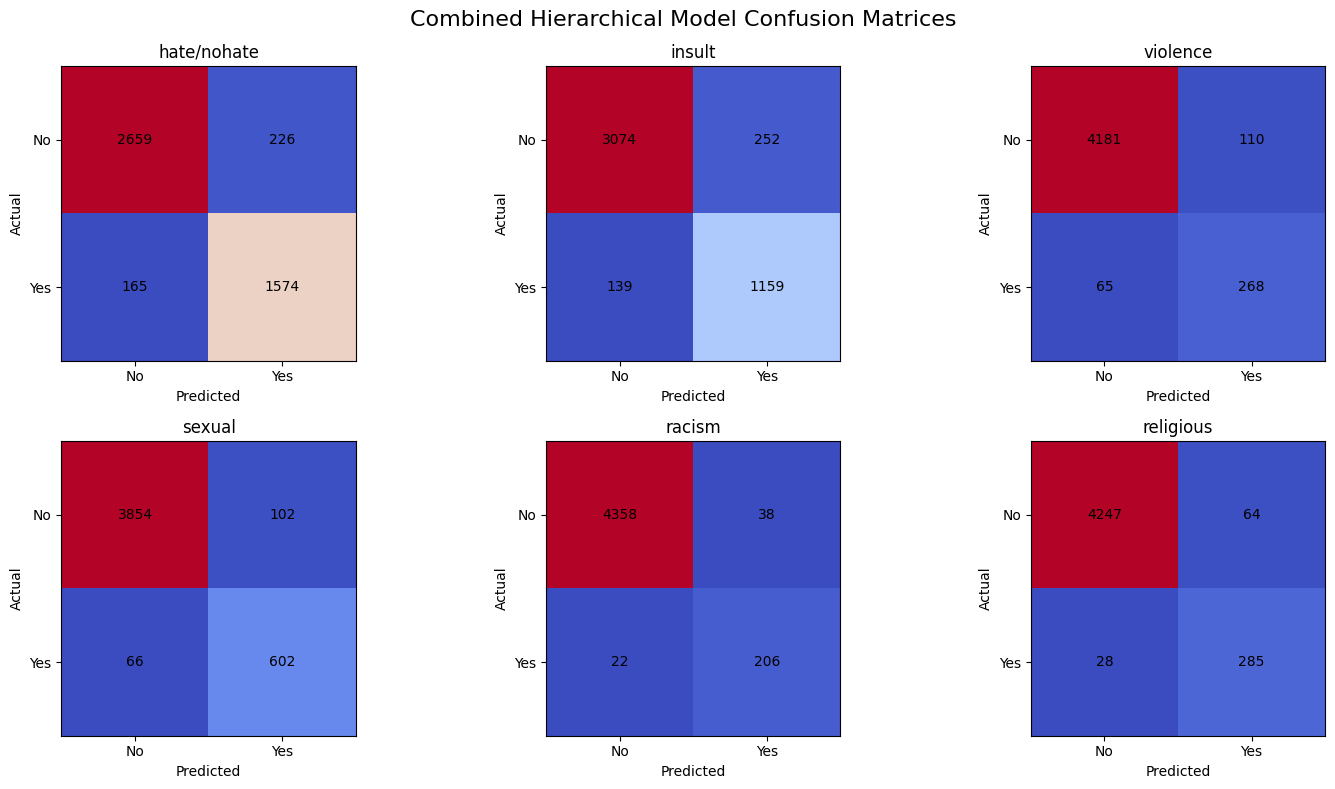

array([[[2659,  226],
        [ 165, 1574]],

       [[3074,  252],
        [ 139, 1159]],

       [[4181,  110],
        [  65,  268]],

       [[3854,  102],
        [  66,  602]],

       [[4358,   38],
        [  22,  206]],

       [[4247,   64],
        [  28,  285]]])

In [ ]:

# STEP 18: Evaluate

print("--- Binary Model Evaluation ---")
binary_eval_results = binary_trainer.evaluate(binary_tokenized["test"])
print(f"Binary Evaluation Results: {binary_eval_results}")

# Get predictions for binary model
binary_preds_output = binary_trainer.predict(binary_tokenized["test"])
binary_y_pred_logits = binary_preds_output.predictions
binary_y_pred_probs = softmax_np(binary_y_pred_logits)[:, 1]
binary_y_pred = (binary_y_pred_probs >= binary_threshold).astype(int)

# True labels for binary test set
binary_y_true = test_df[BINARY_LABEL].values

print("\nBinary Classification Report:")
print(classification_report(binary_y_true, binary_y_pred, target_names=list(binary_id2label.values())))
print("\nBinary Confusion Matrix:")
print(confusion_matrix(binary_y_true, binary_y_pred))

# ROC Curve for Binary Model
fpr, tpr, _ = roc_curve(binary_y_true, binary_y_pred_probs)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Binary Model)")
plt.show()

print("\n--- Subtype Model Evaluation (on Hate-classified texts) ---")
subtype_eval_results = subtype_trainer.evaluate(subtype_tokenized["test"])
print(f"Subtype Evaluation Results: {subtype_eval_results}")

# Get predictions for subtype model
subtype_preds_output = subtype_trainer.predict(subtype_tokenized["test"])
subtype_y_pred_logits = subtype_preds_output.predictions
subtype_y_pred_probs = sigmoid_np(subtype_y_pred_logits)
subtype_y_pred = (subtype_y_pred_probs >= subtype_thresholds).astype(int)

# True labels for subtype test set
subtype_y_true = subtype_tokenized["test"]["labels"]

print("\nSubtype Classification Report:")
print(classification_report(subtype_y_true, subtype_y_pred, target_names=SUBTYPE_COLS, zero_division=0))

print("\n--- Hierarchical Combined Evaluation ---")

# Re-predict binary on the full test_df to ensure alignment
full_binary_test_logits = predict_model_logits(binary_model, test_df["text"].tolist())
full_binary_test_probs = softmax_np(full_binary_test_logits)[:, 1]
full_binary_test_preds = (full_binary_test_probs >= binary_threshold).astype(int)

# Re-predict subtypes on the full test_df (the `predict_model_logits` handles the normalize_text, so use raw test_df[text])
full_subtype_test_logits = predict_model_logits(subtype_model, test_df["text"].tolist())
full_subtype_test_probs = sigmoid_np(full_subtype_test_logits)
full_subtype_test_preds = (full_subtype_test_probs >= subtype_thresholds).astype(int)

# Combine predictions
combined_predictions = combine_hierarchical_predictions(full_binary_test_preds, full_subtype_test_preds)
combined_true_labels = test_df[LABEL_COLS].values

# Calculate and display combined metrics
combined_eval_metrics = combined_metrics(combined_true_labels, combined_predictions)
print("\nHierarchical Combined Metrics:")
for key, value in combined_eval_metrics.items():
    print(f"{key}: {value:.4f}")

# Summarize and plot confusion matrices for combined predictions
_ = summarize_multilabel_confusion_matrices(combined_true_labels, combined_predictions, "Combined Hierarchical Model Confusion Matrices")
plot_multilabel_confusion_matrices(combined_true_labels, combined_predictions, "Combined Hierarchical Model Confusion Matrices")


In [ ]:
# STEP 19: Predict New Texts

def predict_text(text):
    text = clean_text(text)
    encoding = tokenizer(text, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
    encoding = {k:v.to(device) for k,v in encoding.items()}
    output = model(**encoding)
    probs = torch.softmax(output.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    return pred, probs.detach().cpu().numpy()

print(predict_text("यो मान्छे धेरै नराम्रो छ"))  # Nepali
print(predict_text("এই লোকটা খুব খারাপ"))  # Bengali

(1, array([[0.48787764, 0.5121224 ]], dtype=float32))
(1, array([[0.49246165, 0.5075383 ]], dtype=float32))
